# Time Series Analysis Notebook

## 1. Importing Libraries and Loading Data
This section imports the necessary libraries such as pandas, NumPy, matplotlib, and the ARIMA model from statsmodels. The dataset is then loaded from a CSV file and a preview is printed to ensure that the data is correctly loaded.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# Load the dataset
file_path = "Kelloe mains Harvest_2023(2).csv"
df = pd.read_csv(file_path)

# Preview the dataset
print("Dataset preview:")
print(df.head())


Dataset preview:
    Clients         Farms     Fields               Machine Name  \
0  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
1  Mcdonald  kelloe mains     birsby  8400i - SK19 LFR (R Wood)   
2  Mcdonald  kelloe mains     birsby  8400i - SK16 GTY (R Wood)   
3  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
4  Mcdonald  kelloe mains  Craig mae  8500i - SL22 SYY (R Wood)   

           Equipment         Operators Varieties  \
0  1Z08500YANU622386  Unknown Operator   1ST Cut   
1  1Z08400YEKU619149  Unknown Operator   2ND CUT   
2  1Z08400YJGR515326  Unknown Operator   3RD CUT   
3  1Z08500YANU622386  Unknown Operator   4TH CUT   
4  1Z08500YANU622386  Unknown Operator   1ST Cut   

                                            Work     Crop Type  \
0  Forage Harvesting Grass Forage - May 17, 2023  Grass Forage   
1  Forage Harvesting Grass Forage - Jun 13, 2023  Grass Forage   
2  Forage Harvesting Grass Forage - Jul 20, 2023  Grass Forage   
3  

## 2. Data Preprocessing for Time Series Analysis
In this section, the data is preprocessed to prepare for time series analysis:
- The 'First Harvested' column is converted to a datetime format.
- The 'Dry Yield' column is converted to numeric values, with any non-numeric placeholders handled appropriately.
- Rows with missing values in these critical columns are removed.
- The data is sorted by the harvest date.
- The average Dry Yield per day is computed and the time series is set to a daily frequency.


In [9]:
# Convert 'First Harvested' column to datetime format (adjust format as needed)
df['First Harvested'] = pd.to_datetime(df['First Harvested'], format='%b %d, %Y', errors='coerce')
df = df.dropna(subset=['First Harvested'])

# Convert 'Dry Yield' to numeric (handling non-numeric placeholders)
df['Dry Yield'] = pd.to_numeric(df['Dry Yield'].replace('---', np.nan), errors='coerce')
df = df.dropna(subset=['Dry Yield'])

# Sort the data by the harvest date
df = df.sort_values('First Harvested')

# Aggregate the data: calculate the average Dry Yield per day
ts = df.groupby('First Harvested')['Dry Yield'].mean()

# Set the time series index frequency to daily (fills in any missing dates)
ts = ts.asfreq('D')
print("Time series data:")
print(ts.head())


Time series data:
First Harvested
2023-05-16     5.759882
2023-05-17     6.684218
2023-05-18     7.137631
2023-05-19    12.618481
2023-05-20          NaN
Freq: D, Name: Dry Yield, dtype: float64


## 3. Visualizing the Time Series
This section focuses on visualizing the time series data. A line plot of the average Dry Yield over time is generated to help identify trends, seasonal patterns, or anomalies in the data before applying any forecasting models.


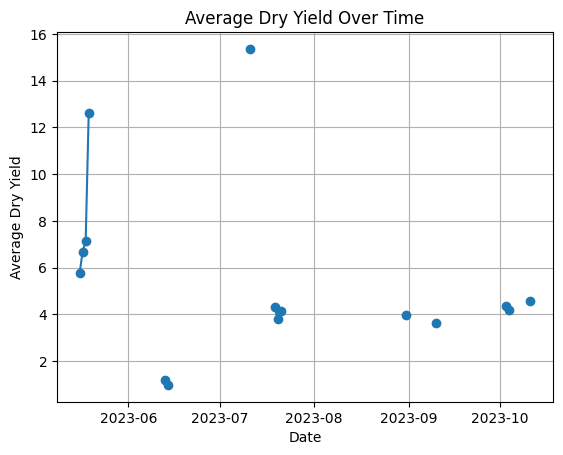

In [10]:
# Block 3: Visualizing the Time Series
plt.figure()
plt.plot(ts.index, ts, marker='o', linestyle='-')
plt.title("Average Dry Yield Over Time")
plt.xlabel("Date")
plt.ylabel("Average Dry Yield")
plt.grid(True)
plt.show()


## 4. Building and Fitting an ARIMA Model
The time series data is split into training and testing sets (e.g., 90% for training, 10% for testing). An ARIMA model with a sample order of (1, 1, 1) is built and fitted using the training data. A summary of the fitted model is printed to review the model parameters and performance.


In [11]:
# Split the time series into training and testing sets (e.g., 90% train, 10% test)
split_point = int(len(ts) * 0.9)
train, test = ts[:split_point], ts[split_point:]

# Build and fit an ARIMA model (example order: ARIMA(1, 1, 1))
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

# Print the ARIMA model summary
print("ARIMA model summary:")
print(model_fit.summary())


ARIMA model summary:
                               SARIMAX Results                                
Dep. Variable:              Dry Yield   No. Observations:                  134
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -32.213
Date:                Fri, 14 Mar 2025   AIC                             70.425
Time:                        22:00:13   BIC                             79.097
Sample:                    05-16-2023   HQIC                            73.949
                         - 09-26-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0464    170.751      0.000      1.000    -334.619     334.712
ma.L1         -0.0311    172.850     -0.000      1.000    -338.812     338.750
sigma2         5.3518      3.52

## 5. Forecasting and Visualizing the Forecast
After fitting the ARIMA model, this section forecasts the test period values. The training data, actual test data, and the model's forecasted values are plotted together. This visualization provides a clear comparison of the model's predictions against the actual observed values.


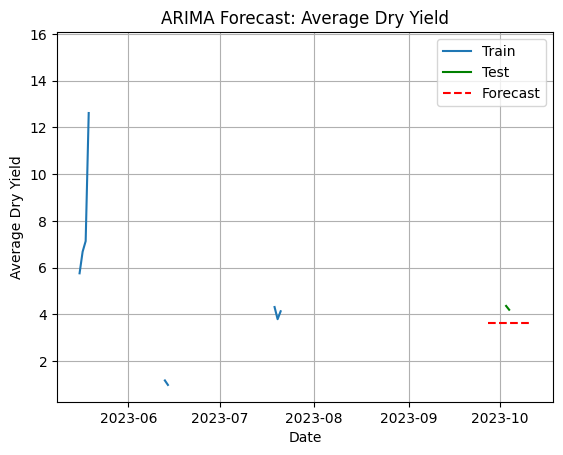

In [12]:
# Forecast the test period based on the fitted model
forecast = model_fit.forecast(steps=len(test))

# Plot the training data, test data, and forecasted values
plt.figure()
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test', color='green')
plt.plot(test.index, forecast, label='Forecast', color='red', linestyle='--')
plt.title("ARIMA Forecast: Average Dry Yield")
plt.xlabel("Date")
plt.ylabel("Average Dry Yield")
plt.legend()
plt.grid(True)
plt.show()


## 6. Future Forecasting
In the final section, the model is used to forecast the average Dry Yield for the next 30 days beyond the available data. A plot is created that combines the historical data with the future forecast, allowing you to observe potential upcoming trends.







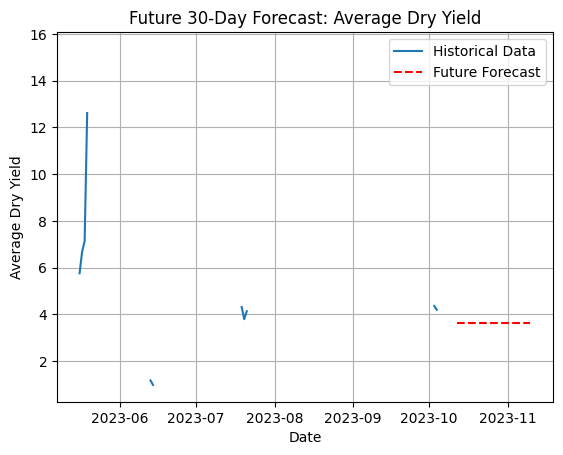

In [13]:
# Forecast the next 30 days beyond the current data
future_forecast = model_fit.forecast(steps=30)

# Plot the historical data and the future forecast
plt.figure()
plt.plot(ts.index, ts, label='Historical Data')
# Create a datetime index for future dates
future_dates = pd.date_range(start=ts.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')
plt.plot(future_dates, future_forecast, label='Future Forecast', color='red', linestyle='--')
plt.title("Future 30-Day Forecast: Average Dry Yield")
plt.xlabel("Date")
plt.ylabel("Average Dry Yield")
plt.legend()
plt.grid(True)
plt.show()
